In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
n_customers = 500

customers = pd.DataFrame({
    "customer_id": range(1, n_customers + 1),
    "gender": np.random.choice(["Male", "Female"], n_customers),
    "age": np.random.randint(18, 70, n_customers),
    "country": np.random.choice(
        ["USA", "Canada", "UK", "Germany", "France", "Spain"],
        n_customers,
        p=[0.35, 0.15, 0.2, 0.1, 0.1, 0.1]
    ),
    "signup_date": pd.to_datetime("2021-01-01") +
                   pd.to_timedelta(
                       np.random.randint(0, 730, n_customers), unit="D"
                   )
})

customers.head()

,customer_id,gender,age,country,signup_date
0,1,Male,38,Spain,2021-05-22
1,2,Female,49,USA,2022-01-11
2,3,Male,40,UK,2022-11-01
3,4,Male,50,Germany,2021-11-20
4,5,Male,20,Canada,2021-05-26


In [4]:
n_orders = 3000

orders = pd.DataFrame({
    "order_id": range(1, n_orders + 1),
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "order_date": pd.to_datetime("2021-01-01") +
                  pd.to_timedelta(
                      np.random.randint(0, 730, n_orders), unit="D"
                  ),
    "order_amount": np.round(
        np.random.gamma(shape=2.0, scale=60.0, size=n_orders), 2
    ),
    "product_category": np.random.choice(
        ["Electronics", "Clothing", "Home", "Sports", "Books"],
        n_orders,
        p=[0.25, 0.3, 0.2, 0.15, 0.1]
    )
})

orders.head()

,order_id,customer_id,order_date,order_amount,product_category
0,1,306,2022-07-15,181.30,Home
1,2,285,2021-03-17,69.41,Home
2,3,185,2021-06-24,60.48,Sports
3,4,39,2021-04-19,113.67,Clothing
4,5,223,2021-07-02,39.77,Clothing


In [5]:
# Bug checking
customers.info()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  500 non-null    int64         
 1   gender       500 non-null    object        
 2   age          500 non-null    int64         
 3   country      500 non-null    object        
 4   signup_date  500 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 19.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          3000 non-null   int64         
 1   customer_id       3000 non-null   int64         
 2   order_date        3000 non-null   datetime64[ns]
 3   order_amount      3000 non-null   float64       
 4   product_category  3000 non-null   object        

In [6]:
## Bug checking
customers.describe()
orders.describe()
# pd does not calculate std for dates



,order_id,customer_id,order_date,order_amount
count,3000.000000,3000.000000,3000,3000.000000
mean,1500.500000,250.485667,2021-12-31 05:08:38.400000,119.314340
min,1.000000,1.000000,2021-01-01 00:00:00,1.610000
25%,750.750000,125.000000,2021-07-02 18:00:00,57.210000
50%,1500.500000,251.000000,2022-01-02 00:00:00,102.410000
75%,2250.250000,379.000000,2022-06-28 00:00:00,161.605000
max,3000.000000,500.000000,2022-12-31 00:00:00,856.940000
std,866.169729,145.000007,NaN,82.951924


In [7]:
total_revenue = orders["order_amount"].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $357,943.02


Total revenue represents the sales volume generated in the analyzed period.

In [8]:
average_order_value = orders["order_amount"].mean()
print(f"Average Order Value (AOV): ${average_order_value:,.2f}")

Average Order Value (AOV): $119.31


AOV indicates the average value of each purchase and allows you to evaluate the typical ticket size.

In [9]:
orders_per_customer = orders.groupby("customer_id")["order_id"].count()

avg_orders_per_customer = orders_per_customer.mean()
max_orders_per_customer = orders_per_customer.max()

print(f"Average orders per customer: {avg_orders_per_customer:.2f}")
print(f"Max orders by a single customer: {max_orders_per_customer}")

Average orders per customer: 6.00
Max orders by a single customer: 14


Most customers make multiple purchases, suggesting moderate recurrence.

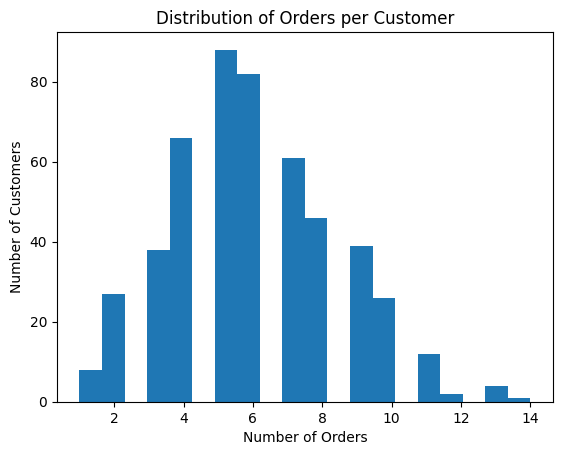

In [10]:
plt.figure()
plt.hist(orders_per_customer, bins=20)
plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

The distribution shows a right tail, indicating that a few customers concentrate a larger number of purchases.

**Key performance indicators** (KPIs) provide an overview of business performance. Total revenue and average order value offer financial context, while order distribution by customer helps to understand recurrence patterns and sales concentration.

The business shows moderate customer recurrence, with an average of 6 orders per customer. While most customers place a limited number of orders, a small group of highly engaged customers contributes disproportionately to total sales.

In [12]:
revenue_by_category = (
    orders
    .groupby("product_category")["order_amount"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category

,order_amount
product_category,
Clothing,104827.83
Electronics,89642.65
Home,73804.51
Sports,54858.94
Books,34809.09


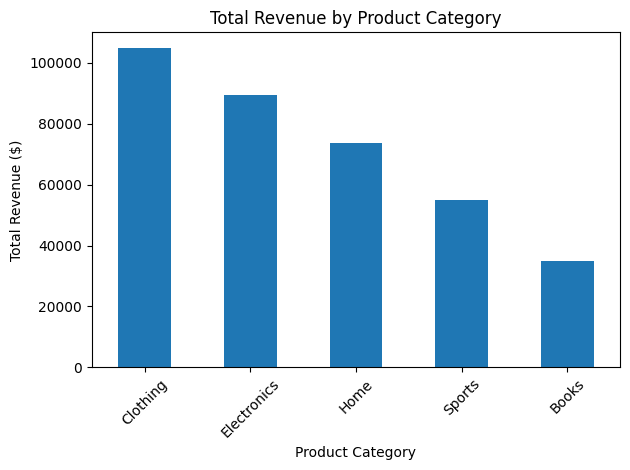

In [13]:
import matplotlib.pyplot as plt

plt.figure()
revenue_by_category.plot(kind="bar")
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The analysis shows that a small number of product categories generate the majority of total revenue. This suggests that customer spending is concentrated in specific categories, which could be prioritized for marketing and inventory decisions.

In [14]:
revenue_by_country = (
    orders
    .merge(customers, on="customer_id")
    .groupby("country")["order_amount"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_country

,order_amount
country,
USA,133675.04
UK,69142.93
Canada,52527.79
Germany,34392.23
France,34190.15
Spain,34014.88


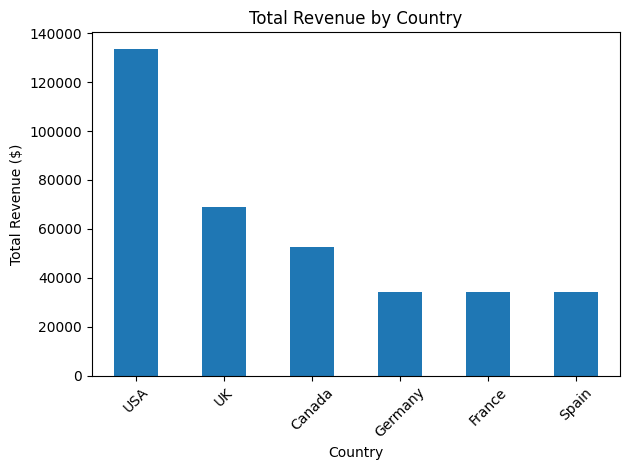

In [15]:
plt.figure()
revenue_by_country.plot(kind="bar")
plt.title("Total Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue is unevenly distributed across countries, with a few countries accounting for most of the sales. This indicates potential core markets where the business has stronger customer demand and higher purchasing power.

In [16]:
total_revenue = orders["order_amount"].sum()

top_3_countries = (
    revenue_by_country.head(3) / total_revenue * 100
).round(2)

top_3_countries

,order_amount
country,
USA,37.35
UK,19.32
Canada,14.67


The top three countries represent a significant percentage of the total revenue, highlighting a high level of geographic concentration. Focusing retention and growth strategies on these markets could have a strong impact on overall business performance.

**📊 Conclusions & Business Takeaways**

🔹 *Key Findings*

The business shows a stable average order value (~$119), suggesting consistent customer purchasing behavior.

A small number of product categories and countries generate a large share of total revenue, indicating concentration of sales.

Customer activity is not evenly distributed: while most customers place a moderate number of orders, a few highly active customers significantly contribute to total revenue.

🔹 *Business Implications*

Product strategy:
High-performing product categories should be prioritized in promotions and stock planning, as they drive most of the revenue.

Market focus:
Countries with the highest revenue contribution represent key markets where customer acquisition and retention efforts could be intensified.

Customer segmentation:
Identifying high-frequency customers could help design loyalty programs to maximize long-term value.

🔹 *Limitations*

The dataset is synthetic and limited in size, which may not fully represent real-world customer behavior.

The analysis focuses on descriptive statistics and does not include predictive modeling.

No seasonality or causal relationships were formally tested.

🔹 *Next Steps (Optional Improvements)*

Perform customer segmentation using clustering techniques.

Analyze customer lifetime value (CLV).

Explore time-series analysis to detect seasonality in sales.

Build simple dashboards to track KPIs over time.